In [43]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



import os
for dirname, _, filenames in os.walk('/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/kervt-kerevitas-gida.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/ttkom-turk-telekom.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/rygyo-reysas-gmyo.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/netas-netas-telekom.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/petkm-petkim.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/vestl-vestel.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/mgros-migros-ticaret.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/tcell-turkcell.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/trkcm-trakya-cam.csv
/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/algyo-alarko-gmyo.csv
/Users/osmandemiroz/development/pythondemos/s

In [46]:

# Dosya yolunu tanımlayın
filepath = '/Users/osmandemiroz/development/pythondemos/stock-prediction-pytorch/data/adana-adana-cimento-a.csv'

# CSV dosyasını pandas ile yükleyin
data = pd.read_csv(filepath)

# Tarih sütununa göre sıralayın
data = data.sort_values('Date')

# İlk birkaç satırı görüntüleyin
print(data.head())


            Date  adjclose   low  high    volume  open
4263  2005-02-22      0.50  0.49  0.51  173144.0  0.50
4262  2005-02-23      0.51  0.49  0.51  168036.0  0.50
4261  2005-02-24      0.51  0.51  0.52   61936.0  0.51
4260  2005-02-25      0.52  0.51  0.52  181572.0  0.51
4259  2005-02-28      0.51  0.51  0.52  167508.0  0.52


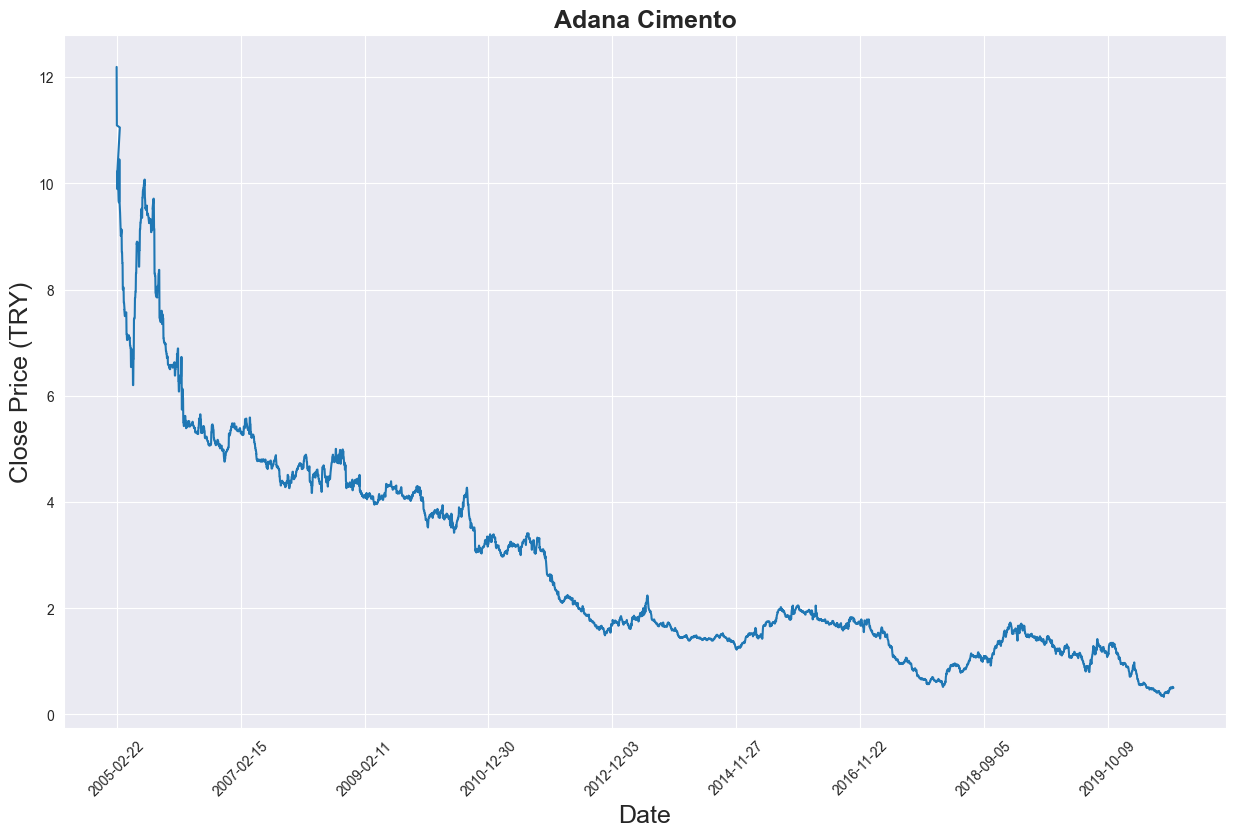

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.figure(figsize = (15,9))
plt.plot(data[['adjclose']])
plt.xticks(range(0,data.shape[0],500),data['Date'].loc[::500],rotation=45)
plt.title("Adana Cimento",fontsize=18, fontweight='bold')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price (TRY)',fontsize=18)
plt.show()

## Normalize data

In [55]:
price = data[['adjclose']]
price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4264 entries, 4263 to 0
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   adjclose  4264 non-null   float64
dtypes: float64(1)
memory usage: 66.6 KB


In [62]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
price['adjclose'] = scaler.fit_transform(price['adjclose'].values.reshape(-1,1))

/var/folders/y5/shcz0y513pn0018slp3fk1l40000gn/T/ipykernel_5691/1811865678.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price['adjclose'] = scaler.fit_transform(price['adjclose'].values.reshape(-1,1))


In [63]:
def split_data(stock, lookback):
    data_raw = stock.to_numpy() # convert to numpy array
    data = []
    
    # create all possible sequences of length seq_len
    for index in range(len(data_raw) - lookback): 
        data.append(data_raw[index: index + lookback])
    
    data = np.array(data);
    test_set_size = int(np.round(0.2*data.shape[0]));
    train_set_size = data.shape[0] - (test_set_size);
    
    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_train, y_train, x_test, y_test]

In [64]:
lookback = 20 # choose sequence length
x_train, y_train, x_test, y_test = split_data(price, lookback)
print('x_train.shape = ',x_train.shape)
print('y_train.shape = ',y_train.shape)
print('x_test.shape = ',x_test.shape)
print('y_test.shape = ',y_test.shape)

x_train.shape =  (3395, 19, 1)
y_train.shape =  (3395, 1)
x_test.shape =  (849, 19, 1)
y_test.shape =  (849, 1)


In [65]:
import torch
import torch.nn as nn

x_train = torch.from_numpy(x_train).type(torch.Tensor)
x_test = torch.from_numpy(x_test).type(torch.Tensor)
y_train_lstm = torch.from_numpy(y_train).type(torch.Tensor)
y_test_lstm = torch.from_numpy(y_test).type(torch.Tensor)
y_train_gru = torch.from_numpy(y_train).type(torch.Tensor)
y_test_gru = torch.from_numpy(y_test).type(torch.Tensor)

In [66]:
input_dim = 1
hidden_dim = 32
num_layers = 2
output_dim = 1
num_epochs = 100

In [67]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [68]:
model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss(reduction='mean')
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

In [69]:
import time

hist = np.zeros(num_epochs)
start_time = time.time()
lstm = []

for t in range(num_epochs):
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_lstm)
    print("Epoch ", t, "MSE: ", loss.item())
    hist[t] = loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
    
training_time = time.time()-start_time
print("Training time: {}".format(training_time))

Epoch  0 MSE:  0.45175546407699585
Epoch  1 MSE:  0.26663312315940857
Epoch  2 MSE:  0.08736574649810791
Epoch  3 MSE:  0.0877421647310257
Epoch  4 MSE:  0.057124100625514984
Epoch  5 MSE:  0.031138572841882706
Epoch  6 MSE:  0.0390314906835556
Epoch  7 MSE:  0.04789381101727486
Epoch  8 MSE:  0.048401884734630585
Epoch  9 MSE:  0.04256581515073776
Epoch  10 MSE:  0.03524954989552498
Epoch  11 MSE:  0.031003015115857124
Epoch  12 MSE:  0.03175657242536545
Epoch  13 MSE:  0.03541356697678566
Epoch  14 MSE:  0.03765843063592911
Epoch  15 MSE:  0.036262400448322296
Epoch  16 MSE:  0.032695427536964417
Epoch  17 MSE:  0.02970229834318161
Epoch  18 MSE:  0.02871832251548767
Epoch  19 MSE:  0.029387639835476875
Epoch  20 MSE:  0.030460219830274582
Epoch  21 MSE:  0.030791401863098145
Epoch  22 MSE:  0.029890218749642372
Epoch  23 MSE:  0.028016729280352592
Epoch  24 MSE:  0.025952927768230438
Epoch  25 MSE:  0.024534808471798897
Epoch  26 MSE:  0.02407475933432579
Epoch  27 MSE:  0.024005839

In [70]:
predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
original = pd.DataFrame(scaler.inverse_transform(y_train_lstm.detach().numpy()))

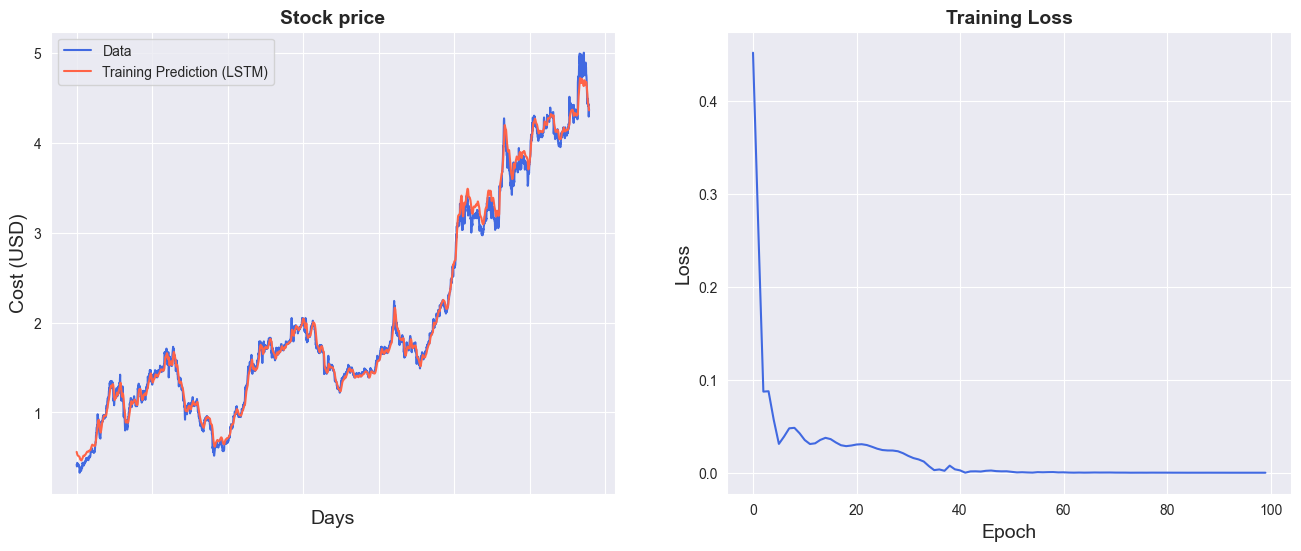

In [71]:
import seaborn as sns
sns.set_style("darkgrid")    

fig = plt.figure()
fig.subplots_adjust(hspace=0.2, wspace=0.2)

plt.subplot(1, 2, 1)
ax = sns.lineplot(x = original.index, y = original[0], label="Data", color='royalblue')
ax = sns.lineplot(x = predict.index, y = predict[0], label="Training Prediction (LSTM)", color='tomato')
ax.set_title('Stock price', size = 14, fontweight='bold')
ax.set_xlabel("Days", size = 14)
ax.set_ylabel("Cost (USD)", size = 14)
ax.set_xticklabels('', size=10)


plt.subplot(1, 2, 2)
ax = sns.lineplot(data=hist, color='royalblue')
ax.set_xlabel("Epoch", size = 14)
ax.set_ylabel("Loss", size = 14)
ax.set_title("Training Loss", size = 14, fontweight='bold')
fig.set_figheight(6)
fig.set_figwidth(16)

In [72]:
import math, time
from sklearn.metrics import mean_squared_error

# make predictions
y_test_pred = model(x_test)

# invert predictions
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler.inverse_transform(y_train_lstm.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler.inverse_transform(y_test_lstm.detach().numpy())

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
print('Test Score: %.2f RMSE' % (testScore))
lstm.append(trainScore)
lstm.append(testScore)
lstm.append(training_time)

Train Score: 0.07 RMSE
Test Score: 1.27 RMSE


In [74]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(price)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[lookback:len(y_train_pred)+lookback, :] = y_train_pred

# shift test predictions for plotting
testPredictPlot = np.empty_like(price)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(y_train_pred)+lookback-1:len(price)-1, :] = y_test_pred

original = scaler.inverse_transform(price['adjclose'].values.reshape(-1,1))

predictions = np.append(trainPredictPlot, testPredictPlot, axis=1)
predictions = np.append(predictions, original, axis=1)
result = pd.DataFrame(predictions)

In [77]:
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[0],
                    mode='lines',
                    name='Train prediction')))
fig.add_trace(go.Scatter(x=result.index, y=result[1],
                    mode='lines',
                    name='Test prediction'))
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[2],
                    mode='lines',
                    name='Actual Value')))
fig.update_layout(
    xaxis=dict(
        showline=True,
        showgrid=True,
        showticklabels=False,
        linecolor='white',
        linewidth=2
    ),
    yaxis=dict(
        title_text='Close (TRY)',
        titlefont=dict(
            family='Rockwell',
            size=12,
            color='white',
        ),
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='white',
        linewidth=2,
        ticks='outside',
        tickfont=dict(
            family='Rockwell',
            size=12,
            color='white',
        ),
    ),
    showlegend=True,
    template = 'plotly_dark'

)



annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                              xanchor='left', yanchor='bottom',
                              text='Results (LSTM)',
                              font=dict(family='Rockwell',
                                        size=26,
                                        color='white'),
                              showarrow=False))
fig.update_layout(annotations=annotations)

fig.show()

In [ ]:
import chart_studio.plotly as py
import chart_studio

chart_studio.tools.set_credentials_file(username='rodolfo_saldanha', api_key='zWJIVWJs23wfiAp516Mh')
py.iplot(fig, filename='stock_prediction_lstm')

In [82]:
class GRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn) = self.gru(x, (h0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [83]:
model = GRU(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss(reduction='mean')
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

In [84]:
hist = np.zeros(num_epochs)
start_time = time.time()
gru = []

for t in range(num_epochs):
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_gru)
    print("Epoch ", t, "MSE: ", loss.item())
    hist[t] = loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

training_time = time.time()-start_time    
print("Training time: {}".format(training_time))

Epoch  0 MSE:  0.3114510178565979
Epoch  1 MSE:  0.07803750783205032
Epoch  2 MSE:  0.034278638660907745
Epoch  3 MSE:  0.08038225769996643
Epoch  4 MSE:  0.04464612528681755
Epoch  5 MSE:  0.0250941701233387
Epoch  6 MSE:  0.036478739231824875
Epoch  7 MSE:  0.0465710274875164
Epoch  8 MSE:  0.04208992421627045
Epoch  9 MSE:  0.02973182499408722
Epoch  10 MSE:  0.02092668227851391
Epoch  11 MSE:  0.022827109321951866
Epoch  12 MSE:  0.029733512550592422
Epoch  13 MSE:  0.02879207953810692
Epoch  14 MSE:  0.020893994718790054
Epoch  15 MSE:  0.015430894680321217
Epoch  16 MSE:  0.01594802550971508
Epoch  17 MSE:  0.018693799152970314
Epoch  18 MSE:  0.01860089972615242
Epoch  19 MSE:  0.014272189699113369
Epoch  20 MSE:  0.00895417109131813
Epoch  21 MSE:  0.007492914795875549
Epoch  22 MSE:  0.009749935939908028
Epoch  23 MSE:  0.008607524447143078
Epoch  24 MSE:  0.003146861679852009
Epoch  25 MSE:  0.001556019182316959
Epoch  26 MSE:  0.005009569227695465
Epoch  27 MSE:  0.003865956

In [85]:
predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
original = pd.DataFrame(scaler.inverse_transform(y_train_gru.detach().numpy()))

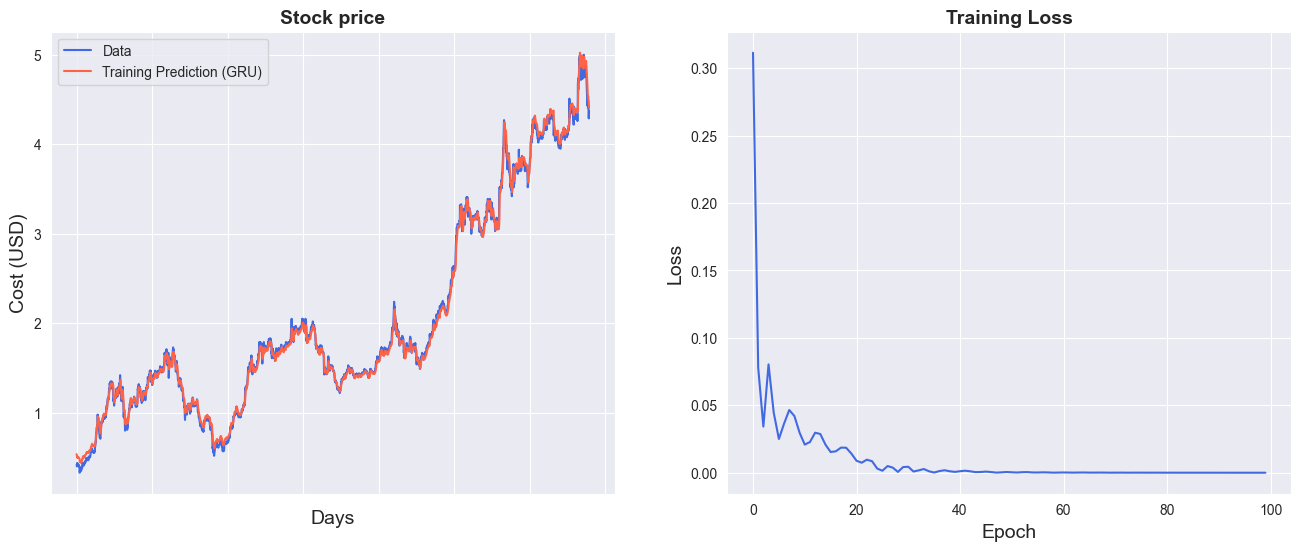

In [86]:
import seaborn as sns
sns.set_style("darkgrid")    

fig = plt.figure()
fig.subplots_adjust(hspace=0.2, wspace=0.2)

plt.subplot(1, 2, 1)
ax = sns.lineplot(x = original.index, y = original[0], label="Data", color='royalblue')
ax = sns.lineplot(x = predict.index, y = predict[0], label="Training Prediction (GRU)", color='tomato')
ax.set_title('Stock price', size = 14, fontweight='bold')
ax.set_xlabel("Days", size = 14)
ax.set_ylabel("Cost (USD)", size = 14)
ax.set_xticklabels('', size=10)


plt.subplot(1, 2, 2)
ax = sns.lineplot(data=hist, color='royalblue')
ax.set_xlabel("Epoch", size = 14)
ax.set_ylabel("Loss", size = 14)
ax.set_title("Training Loss", size = 14, fontweight='bold')
fig.set_figheight(6)
fig.set_figwidth(16)

In [87]:
import math, time
from sklearn.metrics import mean_squared_error

# make predictions
y_test_pred = model(x_test)

# invert predictions
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler.inverse_transform(y_train_gru.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler.inverse_transform(y_test_gru.detach().numpy())

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
print('Test Score: %.2f RMSE' % (testScore))
gru.append(trainScore)
gru.append(testScore)
gru.append(training_time)

Train Score: 0.05 RMSE
Test Score: 0.21 RMSE


In [89]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(price)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[lookback:len(y_train_pred)+lookback, :] = y_train_pred

# shift test predictions for plotting
testPredictPlot = np.empty_like(price)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(y_train_pred)+lookback-1:len(price)-1, :] = y_test_pred

original = scaler.inverse_transform(price['adjclose'].values.reshape(-1,1))

predictions = np.append(trainPredictPlot, testPredictPlot, axis=1)
predictions = np.append(predictions, original, axis=1)
result = pd.DataFrame(predictions)

In [90]:
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[0],
                    mode='lines',
                    name='Train prediction')))
fig.add_trace(go.Scatter(x=result.index, y=result[1],
                    mode='lines',
                    name='Test prediction'))
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[2],
                    mode='lines',
                    name='Actual Value')))
fig.update_layout(
    xaxis=dict(
        showline=True,
        showgrid=True,
        showticklabels=False,
        linecolor='white',
        linewidth=2
    ),
    yaxis=dict(
        title_text='Close (USD)',
        titlefont=dict(
            family='Rockwell',
            size=12,
            color='white',
        ),
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='white',
        linewidth=2,
        ticks='outside',
        tickfont=dict(
            family='Rockwell',
            size=12,
            color='white',
        ),
    ),
    showlegend=True,
    template = 'plotly_dark'

)



annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                              xanchor='left', yanchor='bottom',
                              text='Results (GRU)',
                              font=dict(family='Rockwell',
                                        size=26,
                                        color='white'),
                              showarrow=False))
fig.update_layout(annotations=annotations)

fig.show()

In [91]:
lstm = pd.DataFrame(lstm, columns=['LSTM'])
gru = pd.DataFrame(gru, columns=['GRU'])
result = pd.concat([lstm, gru], axis=1, join='inner')
result.index = ['Train RMSE', 'Test RMSE', 'Train Time']
result

,LSTM,GRU
Train RMSE,0.071559,0.051412
Test RMSE,1.268877,0.206664
Train Time,18.649080,18.097570
